In [6]:
from pathlib import Path
import json
from natsort import natsorted
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib as mpl

In [7]:
# TODO: Decide on plotting with or without lines
# TODO: Make plots for pbcTTT as well?

In [8]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markerlist = ["o", "s", "D"]

mpl.rcParams["font.size"] = 14

BASERESULTSDIR = Path("example_results/")

dirstolabels_dr = {
    "pbc-FFF__defaultgrad__energy": "$U^{1+}$",
    "pbc-FFF__defaultgrad__dr": "default autodiff",
    "pbc-FFF__customjvp__dr": "opt. derivative",
}
dirstolabels_dq = {
    "pbc-FFF__defaultgrad__energy": "",
    "pbc-FFF__defaultgrad__dq": "",
    "pbc-FFF__customjvp__dq": "",
}
dirstolabels_energy_and_dr_and_dq = {
    "pbc-FFF__defaultgrad__energy": "",
    "pbc-FFF__defaultgrad__energy_and_dr_and_dq": "",
    "pbc-FFF__customjvp__energy_and_dr_and_dq": "",
}

quantity_title_dr = r"$\nabla_i U^{1+}$"
quantity_title_dq = r"$\frac{\partial U^{1+}}{\partial q_i}$"
quantity_title_energy_and_dr_and_dq = r"$\left(U^{1+}, \, \nabla_i U^{1+}, \, \frac{\partial U^{1+}}{\partial q_i}\right)$"

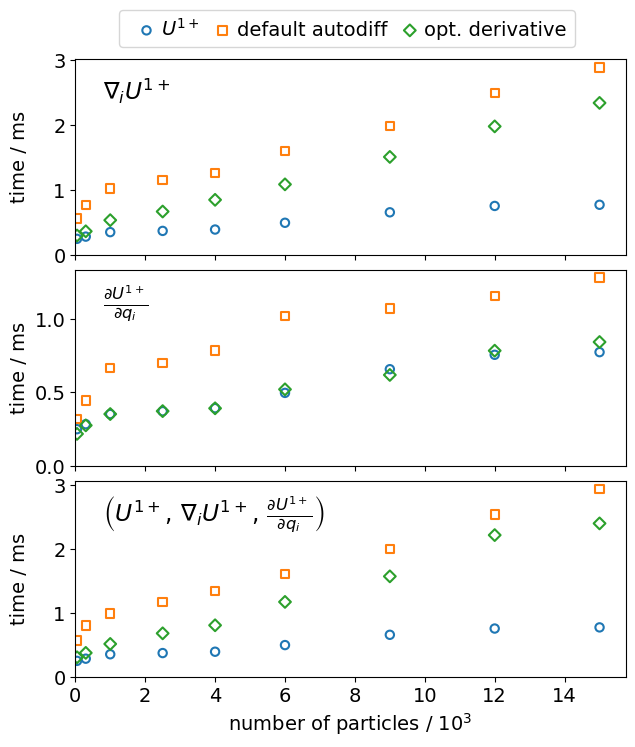

In [9]:
filename_without_suffix = "timing_default_vs_custom_grad__no-lines"

fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    figsize=(6.4, 7.4),
)
axs[-1].set_xlabel("number of particles / $10^3$")

for mapping, quantity, ax in zip(
    [dirstolabels_dr, dirstolabels_dq, dirstolabels_energy_and_dr_and_dq],
    [
        quantity_title_dr,
        quantity_title_dq,
        quantity_title_energy_and_dr_and_dq,
    ],
    axs,
):
    ax.set_ylabel("time / ms")

    for (dirname, label), color, marker in zip(
        mapping.items(), default_colors, markerlist
    ):
        resultsdir = BASERESULTSDIR / dirname

        nbs_particles = onp.loadtxt(
            resultsdir / "times_vs_n_particles.txt", usecols=0, dtype=int
        )
        times = onp.loadtxt(
            resultsdir / "times_vs_n_particles.txt", usecols=1, dtype=float
        )
        ax.scatter(
            nbs_particles / 1000,
            times * 1000,
            label=label,
            marker=marker,
            edgecolor=color,
            facecolor="none",
            linewidth=1.5,
        )
        ax.set_title(quantity, x=0.05, y=0.75, ha="left")

    ax.set_xlim(0, ax.get_xlim()[1])
    ax.set_ylim(0, ax.get_ylim()[1])

plt.subplots_adjust(
    left=0.13, right=0.99, bottom=0.09, top=0.925, hspace=0.075
)
fig.align_ylabels()

axs[0].legend(
    ncols=3,
    handletextpad=-0.25,
    columnspacing=0.15,
    bbox_to_anchor=(0.925, 1.3),
    bbox_transform=axs[0].transAxes,
)

for suffix in ["png", "pdf"]:
    filename_plot = filename_without_suffix + "." + suffix
    fig.savefig(BASERESULTSDIR / (filename_plot))

plt.show()

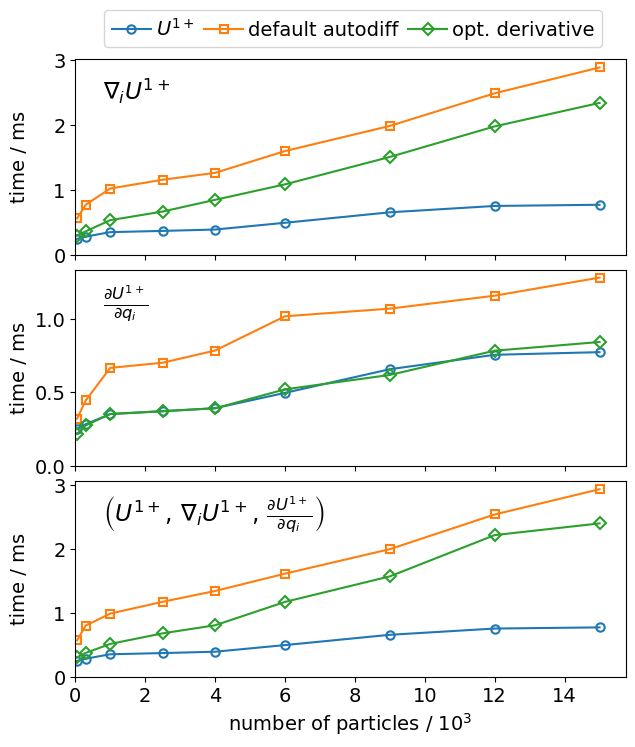

In [10]:
filename_without_suffix = "timing_default_vs_custom_grad__with-lines"

fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    figsize=(6.4, 7.4),
)
axs[-1].set_xlabel("number of particles / $10^3$")

for mapping, quantity, ax in zip(
    [dirstolabels_dr, dirstolabels_dq, dirstolabels_energy_and_dr_and_dq],
    [
        quantity_title_dr,
        quantity_title_dq,
        quantity_title_energy_and_dr_and_dq,
    ],
    axs,
):
    ax.set_ylabel("time / ms")

    for (dirname, label), color, marker in zip(
        mapping.items(), default_colors, markerlist
    ):
        resultsdir = BASERESULTSDIR / dirname

        nbs_particles = onp.loadtxt(
            resultsdir / "times_vs_n_particles.txt", usecols=0, dtype=int
        )
        times = onp.loadtxt(
            resultsdir / "times_vs_n_particles.txt", usecols=1, dtype=float
        )
        ax.plot(
            nbs_particles / 1000,
            times * 1000,
            label=label,
            marker=marker,
            color=color,
            markerfacecolor="none",
            markeredgewidth=1.5,
            # linewidth=1.5,
        )
        ax.set_title(quantity, x=0.05, y=0.75, ha="left")

    ax.set_xlim(0, ax.get_xlim()[1])
    ax.set_ylim(0, ax.get_ylim()[1])

plt.subplots_adjust(
    left=0.13, right=0.99, bottom=0.09, top=0.925, hspace=0.075
)
fig.align_ylabels()

axs[0].legend(
    ncols=3,
    handletextpad=0.25,
    columnspacing=0.5,
    bbox_to_anchor=(0.975, 1.3),
    bbox_transform=axs[0].transAxes,
)

for suffix in ["png", "pdf"]:
    filename_plot = filename_without_suffix + "." + suffix
    fig.savefig(BASERESULTSDIR / (filename_plot))

plt.show()